# E-Commerce Purchase Behavior Analysis — 02 Analysis

How customers pay, what they spend, and whether delivery drives satisfaction.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
df=utils.load_data()
print('orders',len(df))

orders 99441


## 1. Payment methods

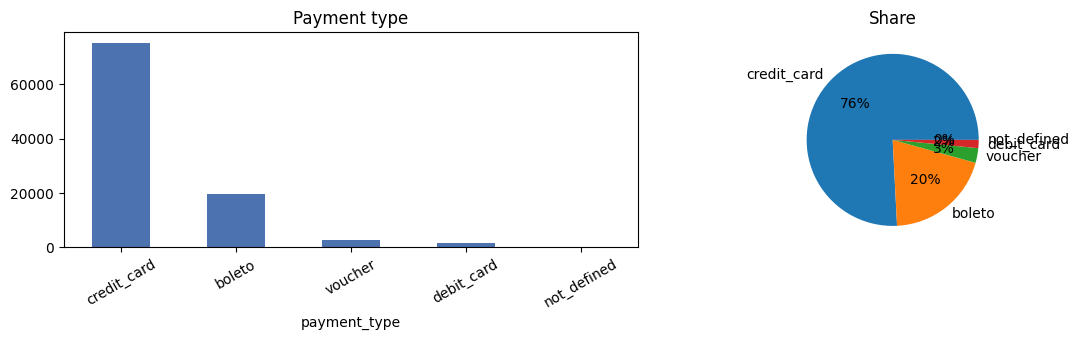

{'credit_card': 75387, 'boleto': 19784, 'voucher': 2739, 'debit_card': 1527, 'not_defined': 3}


In [2]:
pt=df['payment_type'].value_counts()
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
pt.plot(kind='bar',ax=ax[0],color='#4c72b0'); ax[0].set_title('Payment type'); ax[0].tick_params(axis='x',rotation=30)
ax[1].pie(pt,labels=pt.index,autopct='%1.0f%%'); ax[1].set_title('Share')
plt.tight_layout(); plt.show()
print(pt.to_dict())

## 2. Order value & installments

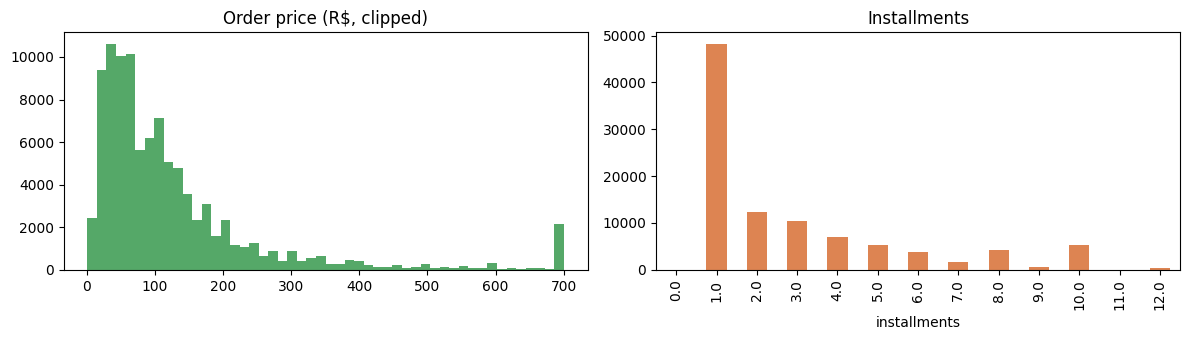

mean price R$137.75  mean freight R$22.87


In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ax[0].hist(df['price'].clip(upper=df['price'].quantile(0.98)),bins=50,color='#55a868'); ax[0].set_title('Order price (R$, clipped)')
df['installments'].dropna().clip(upper=12).value_counts().sort_index().plot(kind='bar',ax=ax[1],color='#dd8452'); ax[1].set_title('Installments')
plt.tight_layout(); plt.show()
print('mean price R$%.2f  mean freight R$%.2f'%(df.price.mean(),df.freight.mean()))

## 3. Review scores

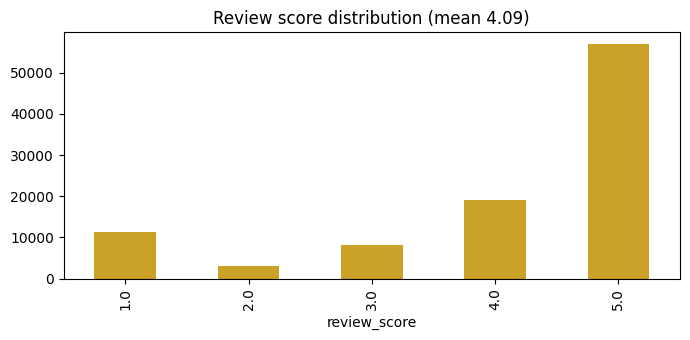

In [4]:
rs=df['review_score'].round().value_counts().sort_index()
fig,ax=plt.subplots(figsize=(7,3.5)); rs.plot(kind='bar',ax=ax,color='#c9a227'); ax.set_title('Review score distribution (mean %.2f)'%df.review_score.mean()); plt.tight_layout(); plt.show()

## 4. Does delivery speed affect the review?

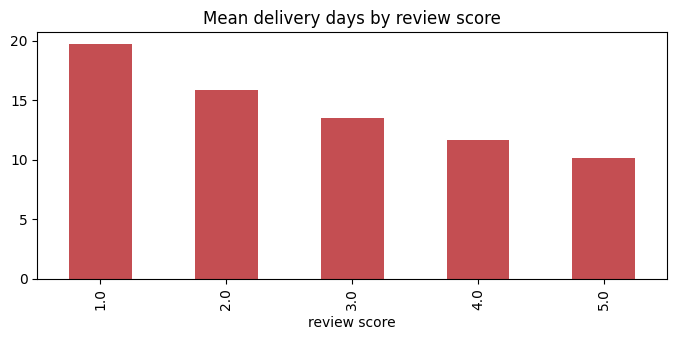

corr(delivery_days, review): -0.343


In [5]:
df['purchase']=pd.to_datetime(df['order_purchase_timestamp'],errors='coerce')
df['delivered']=pd.to_datetime(df['order_delivered_customer_date'],errors='coerce')
df['delivery_days']=(df['delivered']-df['purchase']).dt.days
d=df.dropna(subset=['delivery_days','review_score'])
d=d[(d.delivery_days>=0)&(d.delivery_days<60)]
g=d.groupby(d['review_score'].round())['delivery_days'].mean()
fig,ax=plt.subplots(figsize=(7,3.5)); g.plot(kind='bar',ax=ax,color='#c44e52'); ax.set_title('Mean delivery days by review score'); ax.set_xlabel('review score'); plt.tight_layout(); plt.show()
print('corr(delivery_days, review):',round(d['delivery_days'].corr(d['review_score']),3))

## 5. Key findings

- **99,441 orders, 97% delivered**; mean order **R\$137.75** + **R\$22.87** freight.
- **Credit card dominates (76%)**, then **boleto (20%)** (a Brazil-specific bank slip), voucher and debit trailing.
- **Installment culture is real** — ~half of orders are paid in one instalment, but the long tail spreads purchases over 2–12 months (credit-card instalments are a core Brazilian e-commerce behaviour).
- **Customers are satisfied on average (mean review 4.09/5)**, but reviews are bimodal (lots of 5s and a chunk of 1s).
- **Slow delivery drags reviews down** — mean delivery time is markedly longer for 1-star than 5-star orders (negative delivery-days↔score correlation): logistics, not price, is the satisfaction lever.